# Лабораторная работа 5

Тема: **Регуляризация и нормализация в нейросетях (L2, Dropout, BatchNorm)**  
Цель: на одной и той же задаче (MNIST в PyTorch) изучить, как разные приёмы регуляризации влияют на переобучение и качество обобщения, и сформулировать **свои** выводы по результатам экспериментов.

> Этот ноутбук — заготовка под вашу работу, а не готовый отчёт.  
> Если вы попытаетесь автоматически заполнить его текст генеративной моделью, это проявится в стиле, обобщённости формулировок и несоответствии коду/графикам.
> Оценка ставится за:
> - осмысленный код (который вы можете объяснить),
> - честно проведённые эксперименты,
> - ваши собственные формулировки наблюдений и выводов.

## 1. Ваше предварительное представление о регуляризации

Перед тем как трогать PyTorch, сформулируйте для себя:

1. Что вы называете «переобучением» в контексте нейросетей (на своём языке, без академических определений).  
2. Почему, на ваш взгляд, регуляризация и нормализация могут помочь, если уже и так «всё обучается»?  
3. В чём принципиальная разница между:
   - L2‑штрафом на веса (weight decay),
   - Dropout,
   - BatchNorm — если объяснять их одногруппнику за 2–3 минуты.

Напишите ответы в следующей ячейке. Здесь важен ваш голос, а не повторение чужого текста — не бойтесь неровных формулировок, главное, чтобы они были **вашими**.

In [1]:
pre_intro = """
1) Переобучение это модель как будто слишком хорошо запомнила train, но на новых данных начинает ошибаться. То есть на обучении всё хорошо а на тесте уже хуже

2) Регуляризация нужна чтобы модель не слишком сильно подстраивалась под обучающую выборку. Нормализация тоже помогает потому что данные внутри сети становятся более ровными и обучение идёт спокойнее.

3) L2 просто штрафует слишком большие веса. Dropout во время обучения отключает часть нейронов, чтобы сеть не привыкала к одним и тем же связям. BatchNorm нормализует значения внутри сети и из-за этого обучение обычно становится быстрее и стабильнее.
"""
print(pre_intro)


1) Переобучение это модель как будто слишком хорошо запомнила train, но на новых данных начинает ошибаться. То есть на обучении всё хорошо а на тесте уже хуже

2) Регуляризация нужна чтобы модель не слишком сильно подстраивалась под обучающую выборку. Нормализация тоже помогает потому что данные внутри сети становятся более ровными и обучение идёт спокойнее.

3) L2 просто штрафует слишком большие веса. Dropout во время обучения отключает часть нейронов, чтобы сеть не привыкала к одним и тем же связям. BatchNorm нормализует значения внутри сети и из-за этого обучение обычно становится быстрее и стабильнее.



## 2. Импорт и настройка среды

Сделайте стандартную подготовку:
- импортируйте PyTorch, torchvision и необходимые утилиты;
- зафиксируйте **один** seed (свой, не «магический» 42), чтобы эксперименты можно было воспроизвести;
- определите, есть ли CUDA, но пишите код так, чтобы и на CPU всё работало.


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ВАШ SEED (запишите его потом в отчёте)
MY_SEED = 67
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 67


## 3. Данные MNIST и базовая предобработка

Вы уже работали с MNIST в ЛР4, так что здесь не должно быть сюрпризов.  
Задача на этом шаге:
- загрузить train/test;
- применить `ToTensor` и нормализацию (можно стандартную для MNIST);
- выбрать размер батча так, чтобы обучение шло достаточно быстро, но не превращалось в «шум».  

Важно: число `batch_size`, нормализацию и все прочие решения потом нужно будет **объяснить** в отчёте, а не «так было в шаблоне».

In [ ]:
batch_size =128
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

100%|██████████| 9.91M/9.91M [00:00<00:00, 25.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 624kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.05MB/s]

train size = 60000
test size  = 10000
batch_size = 128


Быстро посмотрим на несколько картинок, чтобы убедиться, что всё загружается и отображается как ожидается.


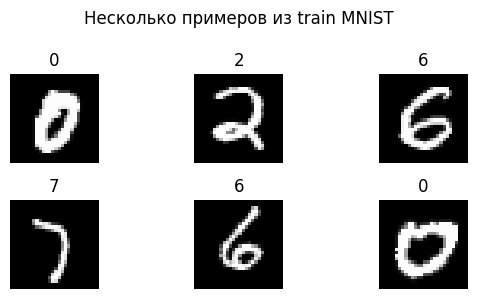

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"{labels[i].item()}")
    plt.axis("off")
plt.suptitle("Несколько примеров из train MNIST")
plt.tight_layout()
plt.show()

### Ваши короткие наблюдения по данным

Ответьте здесь буквально в 3–5 предложениях:
- насколько «чистыми» и различимыми кажутся цифры;
- есть ли такие изображения, которые уже сейчас вы бы сами классифицировали с сомнением.

Не пытайтесь «угадывать правильный ответ» — это просто ваши наблюдения.

In [2]:
data_impression = """
Цифры в целом выглядят нормально и их можно распознать. Но некоторые написаны не идеально, например 2 и 7 немного кривые. Поэтому понятно, почему модель иногда может ошибаться на MNIST.
"""
print(data_impression)


Цифры в целом выглядят нормально и их можно распознать. Но некоторые написаны не идеально, например 2 и 7 немного кривые. Поэтому понятно, почему модель иногда может ошибаться на MNIST.



## 4. Три варианта модели

Мы будем сравнивать три архитектурных варианта на одной и той же задаче:

1. **BaseMLP** — без регуляризации (кроме implicit нормализации входа).  
2. **DropoutMLP** — тот же каркас, но с Dropout в скрытых слоях.  
3. **BatchNormMLP** — тот же каркас, но со слоями BatchNorm1d.

L2‑регуляризацию (weight_decay) будем добавлять через оптимизатор к любому из вариантов.

Архитектуру берите не слишком маленькую (чтобы сеть могла переобучиться), но и не чрезмерную.


In [ ]:
hide1 = 512
hide2 = 256

class BaseMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, hide1),
            nn.ReLU(),
            nn.Linear(hide1, hide2),
            nn.ReLU(),
            nn.Linear(hide2, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class DropoutMLP(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, hide1),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(hide1, hide2),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(hide2, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)


class BatchNormMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, hide1),
            nn.BatchNorm1d(hide1),
            nn.ReLU(),
            nn.Linear(hide1, hide2),
            nn.BatchNorm1d(hide2),
            nn.ReLU(),
            nn.Linear(hide2, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(BaseMLP())
print(DropoutMLP())
print(BatchNormMLP())

BaseMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
DropoutMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)
BatchNormMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): B

В отчёте вы потом отдельно опишете:
- какие именно размеры слоёв и значения Dropout использовали;
- пробовали ли другие варианты (и чем они закончились).

## 5. Общие функции обучения и оценки

Чтобы не копировать код, напишем универсальные функции:
- `train_one_epoch` — один проход по train;
- `evaluate` — оценка на любом DataLoader.

Если вы хотите добавить дополнительные метрики/логирование — делайте это здесь и прокомментируйте в отчёте.


In [ ]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Функция запуска эксперимента для одной конфигурации

Чтобы аккуратно сравнивать разные варианты (без регуляризации, с L2, с Dropout, с BatchNorm), удобно иметь одну функцию `run_experiment`, которая:
- создаёт модель;
- настраивает оптимизатор (с нужным `weight_decay` и `lr`);
- обучает модель `num_epochs` эпох;
- возвращает историю `loss/accuracy`.

Важный момент: вы сами выбираете числа эпох, шаг обучения и значения L2/Dropout, но потом должны будете указать их в отчёте и прокомментировать.


In [ ]:
def run_experiment(model_class, config_name,
                   weight_decay=0.0, dropout_p=0.5,
                   num_epochs=8, lr=1e-3):
    print("\n=== Конфигурация:", config_name, "===")

    # создаём модель нужного класса
    if model_class is DropoutMLP:
        model = model_class(p=dropout_p).to(device)
    else:
        model = model_class().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "train_acc": [],
               "test_loss": [], "test_acc": []}

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

    return model, history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор экспериментов (пример)

Рекомендуется провести, как минимум, такие эксперименты:

1. `Base / no_reg` — BaseMLP, `weight_decay=0`.  
2. `Base / L2` — BaseMLP, `weight_decay` (например, `1e-4` или `1e-3`).  
3. `Dropout p=0.5` — DropoutMLP, без L2 для чистоты.  
4. `BatchNorm` — BatchNormMLP, без L2 для начала.  

При желании можно добавить комбинации (BatchNorm + L2, Dropout + L2), но важно успеть осмысленно проанализировать хотя бы базовые варианты.


In [ ]:
# 1. Базовая модель без регуляризации
base_model, base_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / no_reg",
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: Base / no_reg ===
Эпоха 1/8 | train_loss=0.2325, train_acc=0.9305, test_loss=0.1020, test_acc=0.9682
Эпоха 2/8 | train_loss=0.0886, train_acc=0.9721, test_loss=0.1004, test_acc=0.9679
Эпоха 3/8 | train_loss=0.0579, train_acc=0.9821, test_loss=0.0745, test_acc=0.9764
Эпоха 4/8 | train_loss=0.0446, train_acc=0.9856, test_loss=0.0689, test_acc=0.9784
Эпоха 5/8 | train_loss=0.0354, train_acc=0.9887, test_loss=0.0691, test_acc=0.9781
Эпоха 6/8 | train_loss=0.0278, train_acc=0.9908, test_loss=0.0694, test_acc=0.9827
Эпоха 7/8 | train_loss=0.0215, train_acc=0.9929, test_loss=0.0771, test_acc=0.9781
Эпоха 8/8 | train_loss=0.0225, train_acc=0.9926, test_loss=0.0754, test_acc=0.9805


In [ ]:
# 2. Базовая модель с L2 (weight decay)
l2_model, l2_hist = run_experiment(
    model_class=BaseMLP,
    config_name="Base / L2 (wd=1e-4)",
    weight_decay=1e-4,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: Base / L2 (wd=1e-4) ===
Эпоха 1/8 | train_loss=0.2355, train_acc=0.9291, test_loss=0.1389, test_acc=0.9557
Эпоха 2/8 | train_loss=0.0923, train_acc=0.9718, test_loss=0.0856, test_acc=0.9717
Эпоха 3/8 | train_loss=0.0621, train_acc=0.9804, test_loss=0.0750, test_acc=0.9767
Эпоха 4/8 | train_loss=0.0486, train_acc=0.9841, test_loss=0.0766, test_acc=0.9776
Эпоха 5/8 | train_loss=0.0387, train_acc=0.9873, test_loss=0.0705, test_acc=0.9798
Эпоха 6/8 | train_loss=0.0328, train_acc=0.9893, test_loss=0.0838, test_acc=0.9750
Эпоха 7/8 | train_loss=0.0293, train_acc=0.9903, test_loss=0.0728, test_acc=0.9811
Эпоха 8/8 | train_loss=0.0264, train_acc=0.9913, test_loss=0.0721, test_acc=0.9814


In [ ]:
# 3. Модель с Dropout
drop_model, drop_hist = run_experiment(
    model_class=DropoutMLP,
    config_name="Dropout p=0.5",
    dropout_p=0.5,
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: Dropout p=0.5 ===
Эпоха 1/8 | train_loss=0.3447, train_acc=0.8930, test_loss=0.1336, test_acc=0.9575
Эпоха 2/8 | train_loss=0.1710, train_acc=0.9484, test_loss=0.1004, test_acc=0.9693
Эпоха 3/8 | train_loss=0.1440, train_acc=0.9567, test_loss=0.0850, test_acc=0.9743
Эпоха 4/8 | train_loss=0.1257, train_acc=0.9627, test_loss=0.0826, test_acc=0.9746
Эпоха 5/8 | train_loss=0.1101, train_acc=0.9667, test_loss=0.0738, test_acc=0.9783
Эпоха 6/8 | train_loss=0.1058, train_acc=0.9676, test_loss=0.0721, test_acc=0.9777
Эпоха 7/8 | train_loss=0.0977, train_acc=0.9698, test_loss=0.0827, test_acc=0.9757
Эпоха 8/8 | train_loss=0.0929, train_acc=0.9717, test_loss=0.0706, test_acc=0.9797


In [ ]:
# 4. Модель с BatchNorm
bn_model, bn_hist = run_experiment(
    model_class=BatchNormMLP,
    config_name="BatchNorm",
    weight_decay=0.0,
    num_epochs=8,
    lr=1e-3
)


=== Конфигурация: BatchNorm ===
Эпоха 1/8 | train_loss=0.1855, train_acc=0.9472, test_loss=0.0822, test_acc=0.9738
Эпоха 2/8 | train_loss=0.0714, train_acc=0.9778, test_loss=0.0721, test_acc=0.9757
Эпоха 3/8 | train_loss=0.0479, train_acc=0.9847, test_loss=0.0649, test_acc=0.9787
Эпоха 4/8 | train_loss=0.0343, train_acc=0.9889, test_loss=0.0704, test_acc=0.9773
Эпоха 5/8 | train_loss=0.0255, train_acc=0.9919, test_loss=0.0615, test_acc=0.9806
Эпоха 6/8 | train_loss=0.0215, train_acc=0.9930, test_loss=0.0657, test_acc=0.9804
Эпоха 7/8 | train_loss=0.0193, train_acc=0.9935, test_loss=0.0659, test_acc=0.9809
Эпоха 8/8 | train_loss=0.0145, train_acc=0.9951, test_loss=0.0735, test_acc=0.9796


## 8. Визуальное сравнение кривых

Теперь важно не просто посмотреть на финальные числа, а **сравнить динамику** обучения для разных вариантов:
как меняются train/test loss и accuracy по эпохам.

Сделаем один общий график для всех конфигураций.


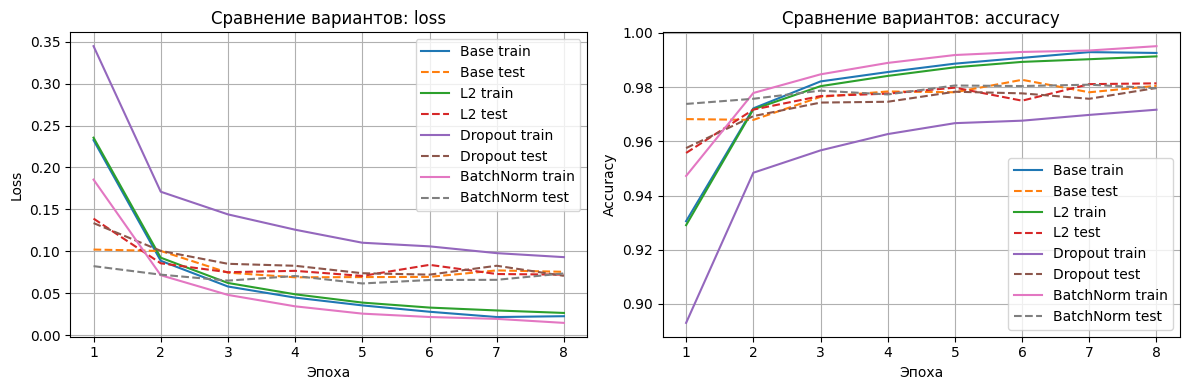

In [ ]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(
    histories=[base_hist, l2_hist, drop_hist, bn_hist],
    labels=["Base", "L2", "Dropout", "BatchNorm"],
    title_prefix="Сравнение вариантов: "
)

## 9. Ваш разбор результатов

Теперь самая важная (и самая «анти‑генеративная») часть: **живой разбор** того, что вы увидели на графиках и в числах.

Постарайтесь ответить (в свободной форме, без маркированного списка):

- Как вёл себя разрыв между train и test для базовой модели? Было ли заметное переобучение уже к 8‑й эпохе?  
- Что дало добавление L2: стало ли train хуже, а test лучше/стабильнее?  
- Как ведёт себя Dropout: не «ломает» ли он обучение в начале, не делает ли train слишком шумным?  
- Что меняет BatchNorm: меняется ли скорость выхода на насыщение по точности, становятся ли кривые «ровнее»?  
- Если нужно было выбрать **одну** технику регуляризации для этой задачи, что бы вы выбрали и почему (с опорой на ваши конкретные графики и числа)?

Не стесняйтесь упоминать неудачные настройки (слишком большой weight_decay, странный Dropout и т.п.) — это тоже часть обучения.


In [6]:
analysis_comment = """
Базовая модель обучилась нормально, train_acc дошел до 0.9926, но test_acc к концу был 0.9805. На графике видно что примерно с 5-6 эпохи train продолжает расти, а test начинает немного болтаться вокруг одного значения — лучший был 0.9827 на 6 эпохе, потом чуть хуже. Переобучение есть, небольшое, но заметное.

С L2 (weight_decay=1e-4) train стал чуть скромнее — 0.9913 против 0.9926, зато test вышел 0.9814, это лучший финальный результат из всех четырёх. Разрыв между train и test меньше чем у базовой, кривые на графике идут чуть плотнее друг к другу.

Dropout в начале реально тормозит — train_acc на 1-й эпохе 0.8930, когда у остальных уже 0.93+. Это хорошо видно на графике loss, фиолетовая линия train держится выше до самого конца и финишировала на 0.9717. При этом test_acc вышел 0.9797 — нормально, и разрыв между train и test у дропаута самый маленький. То есть переобучения почти нет, но за это платишь медленным обучением.

BatchNorm мне понравился тем что быстро вышел на хорошую точность — уже на первых эпохах результат был лучше чем у остальных. Лучший test_acc был 0.9809 на 7 эпохе, в конце 0.9796. Кривые на графике ровные, без скачков.

Если выбирать одну технику — я бы взял L2. По финальному test_acc он лучший (0.9814), при этом ничего не ломает в обучении и не замедляет его. BatchNorm тоже хороший вариант если важна скорость выхода на хорошую точность.
"""
print(analysis_comment)


Базовая модель обучилась нормально, train_acc дошел до 0.9926, но test_acc к концу был 0.9805. На графике видно что примерно с 5-6 эпохи train продолжает расти, а test начинает немного болтаться вокруг одного значения — лучший был 0.9827 на 6 эпохе, потом чуть хуже. Переобучение есть, небольшое, но заметное.

С L2 (weight_decay=1e-4) train стал чуть скромнее — 0.9913 против 0.9926, зато test вышел 0.9814, это лучший финальный результат из всех четырёх. Разрыв между train и test меньше чем у базовой, кривые на графике идут чуть плотнее друг к другу.

Dropout в начале реально тормозит — train_acc на 1-й эпохе 0.8930, когда у остальных уже 0.93+. Это хорошо видно на графике loss, фиолетовая линия train держится выше до самого конца и финишировала на 0.9717. При этом test_acc вышел 0.9797 — нормально, и разрыв между train и test у дропаута самый маленький. То есть переобучения почти нет, но за это платишь медленным обучением.

BatchNorm мне понравился тем что быстро вышел на хорошую точно

## 10. Итоговое резюме по лабораторной работе

В конце сформулируйте короткое резюме (5–8 предложений):

- Какие **конкретные** настройки (архитектура, lr, weight_decay, Dropout‑p, число эпох) вы в итоге считаете для этой задачи «золотой серединой» и почему.  
- Чем ваши ожидания по эффекту регуляризации совпали / не совпали с тем, что вы реально увидели.  
- Как вы теперь объяснили бы одногруппнику, когда есть смысл использовать L2, когда Dropout, а когда BatchNorm — именно на примере **ваших** экспериментов, а не абстрактной теории.


In [4]:
final_summary = """
В этой лабе я сравнил обычную MLP модель, L2, Dropout и BatchNorm на MNIST. Архитектура была 784 -> 512 -> 256 -> 10, batch_size = 128, lr = 1e-3 и 8 эпох.
Лучше всего по финальной точности на тесте получилась модель с L2: test_acc = 0.9814. Базовая модель тоже дала хороший результат, но у нее заметно что train_acc выше, чем test_acc поэтому есть небольшое переобучение
Dropout с p=0.5 обучался медленнее, зато train_acc был ниже и модель не так сильно подстраивалась под train. BatchNorm быстро вышел на хорошую точность и в целом обучался ровно.
В итоге для этой задачи я бы выбрал L2, потому что он дал лучший финальный test_acc и при этом не сильно усложняет модель. BatchNorm тоже хороший вариант, если важна скорость и стабильность обучения.
"""
print(final_summary)


В этой лабе я сравнил обычную MLP модель, L2, Dropout и BatchNorm на MNIST. Архитектура была 784 -> 512 -> 256 -> 10, batch_size = 128, lr = 1e-3 и 8 эпох.
Лучше всего по финальной точности на тесте получилась модель с L2: test_acc = 0.9814. Базовая модель тоже дала хороший результат, но у нее заметно что train_acc выше, чем test_acc поэтому есть небольшое переобучение
Dropout с p=0.5 обучался медленнее, зато train_acc был ниже и модель не так сильно подстраивалась под train. BatchNorm быстро вышел на хорошую точность и в целом обучался ровно.
В итоге для этой задачи я бы выбрал L2, потому что он дал лучший финальный test_acc и при этом не сильно усложняет модель. BatchNorm тоже хороший вариант, если важна скорость и стабильность обучения.

